##Latin Example

C:\Users\thepe\AppData\Roaming\Python\Python312\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


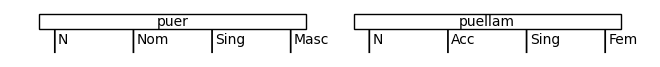

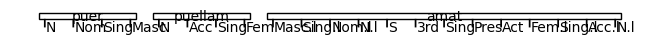

ValueError: left and right need to be adjoints

In [1]:
from lambeq.backend.drawing import draw
from lambeq.backend.grammar import Cap, Cup, Id, Ty, Word
from lambeq import SpacyTokeniser
from lambeq import BobcatParser
from lambeq import Rewriter
# Basic types for nouns, sentences, verbs
N = Ty('N')    # Noun (Subject or Object)
S = Ty('S')    # Sentence (finite verb structure)

# Verb features for person, tense-mood, and voice
Person = {
    '1': Ty('1st'),
    '2': Ty('2nd'),
    '3': Ty('3rd')
}

TenseMood = {
    'Pres': Ty('Pres'),
    'Perf': Ty('Perf'),
    'Impv': Ty('Impv'),
    'Fut': Ty('Fut'),
}

Voice = {
    'Act': Ty('Act'),
    'Pass': Ty('Pass'),
}

# Cases for noun inflections
Case = {
    'Nom': Ty('Nom'),  # Nominative (Subject)
    'Acc': Ty('Acc'),  # Accusative (Object)
    'Gen': Ty('Gen'),  # Genitive
    'Dat': Ty('Dat'),  # Dative
    'Abl': Ty('Abl'),  # Ablative
}

# Gender and Number
Gender = {
    'Masc': Ty('Masc'),
    'Fem': Ty('Fem'),
    'Neut': Ty('Neut'),
}

Number = {
    'Sing': Ty('Sing'),
    'Plur': Ty('Plur')
}
def verb_type(subject_case, subject_number, subject_gender,
              object_case, object_number, object_gender,
              person='3', number='Sing', tense_mood='Pres', voice='Act'):
    subject = N @ Case[subject_case] @ Number[subject_number] @ Gender[subject_gender]
    obj = N @ Case[object_case] @ Number[object_number] @ Gender[object_gender]
    verb_features = Person[person] @ Number[number] @ TenseMood[tense_mood] @ Voice[voice]
    return subject.l @ S @ verb_features @ obj.l
# Define word types
puer = Word('puer', N @ Case['Nom'] @ Number['Sing'] @ Gender['Masc'])  # Nominative
puellam = Word('puellam', N @ Case['Acc'] @ Number['Sing'] @ Gender['Fem'])  # Accusative

# Define verb type for "amat"
amat = Word('amat', verb_type('Nom', 'Sing', 'Masc', 'Acc', 'Sing', 'Fem'))

# Build noun phrase: subject (puer) + object (puellam)
noun_phrase = puer @ puellam

# Combine noun phrase with verb
sentence = noun_phrase @ amat
draw(noun_phrase)
draw(sentence)
# Connect nouns to verb's expected inputs
diagram_sentence = sentence >> Cup(puer.cod[-1], amat.cod[0]) >> Cup(puellam.cod[-1], amat.cod[-1])

# Rewriting step to simplify the diagram
rewriter = Rewriter(['cups'])
simplified_diagram = rewriter(diagram_sentence)

# Draw the final diagram
simplified_diagram.draw(figsize=(12, 6), fontsize=12)


##Adapting Latin Model to Sanskrit
A Computational Algebraic Approach to Latin
Grammar
CLAUDIA CASADIO and JIM LAMBEK1 https://link.springer.com/article/10.1007/s11168-005-1286-0
Tones
In **Vedic Sanskrit**, the language of the ancient Indian Vedas, the **three tones**—**udātta**, **anudātta**, and **svarita**—serve critical grammatical and phonological functions. These tones are not merely phonetic variations but integral to the language's syntax and semantics, affecting the meaning of words and sentences.

---

### **Grammatical Functions of the Three Tones**

1. **Udātta (उदात्त)**: This is the **raised** or **high-pitched** tone. It is the primary accent and is often unmarked in Vedic texts because it is considered the default or central tone.

2. **Anudātta (अनुदात्त)**: The **low-pitched** or **unaccented** tone. It usually precedes the udātta syllable and is marked with a horizontal line below the syllable.

3. **Svarita (स्वरित)**: The **falling** or **combination** tone. It occurs when an udātta is immediately followed by an anudātta within the same syllable. It is marked with a small vertical line above the syllable.

#### **Key Grammatical Roles:**

- **Distinguishing Word Meanings**: The tones can differentiate between words that are otherwise spelled the same but have different meanings.

- **Indicating Grammatical Relationships**: They help in marking grammatical functions such as subject and object, especially in compounds.

- **Affecting Semantic Interpretation**: Incorrect use of tones can change who is performing an action and who is receiving it.

---

### **The Story of King Tvaṣṭā and Indra**

This story illustrates the profound impact that the correct use of tones has on meaning in Vedic Sanskrit.

#### **Background:**

- **Tvaṣṭā**: A divine artisan or a powerful sage in Vedic mythology.
- **Indra**: The king of the gods, known for his strength and warrior skills.

#### **The Tale:**

1. **Desire for Vengeance**: Tvaṣṭā's son, **Viśvarūpa**, was killed by Indra. Seeking revenge, Tvaṣṭā decided to perform a sacred ritual to beget a son who would slay Indra.

2. **The Sacrificial Chant**:

   - Tvaṣṭā was supposed to chant:

     ```
     "indrá-śatrur vardhasva"
     ```

     Meaning: "*Grow, O slayer of Indra!*"

   - Here, **indrá-śatrur** (with the accent on "śatru") means "slayer of Indra," making Indra the **object** of the action.

3. **Mispronunciation of Tones**:

   - Tvaṣṭā incorrectly pronounced the chant as:

     ```
     "índra-śatrur vardhasva"
     ```

     Placing the udātta (accent) on "índra" instead of "śatru."

   - This changed **indrá-śatrur** to **índra-śatrur**, altering the compound's grammatical function.

4. **Grammatical Implications**:

   - **Correct Accentuation**: **indrá-śatrur** (Indra as object)

     - **Meaning**: "One who slays **Indra**."

   - **Incorrect Accentuation**: **índra-śatrur** (Indra as subject)

     - **Meaning**: "**Indra**, who is a slayer."

     - This shifts Indra from being the one who is slain to the one who slays.

5. **Consequences**:

   - The mispronunciation resulted in the birth of **Vṛtra**, a demon destined to be slain by Indra, not to slay Indra.

   - Despite Tvaṣṭā's intentions, his son was ultimately killed by Indra, fulfilling the unintended meaning of the mispronounced mantra.

---

### **Analysis of the Grammatical Function of Tones in the Story**

#### **1. Compound Formation and Accentuation**

- **Tatpuruṣa Compound**: A compound where the second element is the principal one, and the first element modifies it.

  - **indrá-śatru**: "Indra's enemy" or "slayer of Indra."

- **Bahuvrīhi Compound**: A compound that describes a person or object by what it possesses.

  - **índra-śatru**: "One whose enemy is Indra," implying Indra is the one performing the action.

#### **2. Role of Tones in Determining Meaning**

- **Accent Placement**: In Vedic Sanskrit, the placement of the udātta accent can change the type of compound and thus alter the syntactic relationship between the words.

- **Subject vs. Object**:

  - **indrá-śatrur**: Indra is the object (**accusative case**), and the son is the subject who will perform the action of slaying.

  - **índra-śatrur**: Indra is the subject (**nominative case**), becoming the one who will slay.

---

### **Significance and Implications**

#### **Grammatical Importance**

- **Precision in Rituals**: The story underscores the necessity for precise pronunciation in Vedic rituals, where mantras must be chanted with exact tonal and phonetic accuracy to achieve the desired effect.

- **Grammatical Functions of Tones**:

  - **Syntax**: Tones help establish the grammatical relationships between words in a sentence.

  - **Semantics**: They affect the meaning conveyed by those grammatical relationships.

#### **Cultural and Linguistic Impact**

- **Oral Tradition**: Vedic Sanskrit was primarily transmitted orally. Tones served as auditory markers to preserve the integrity of the texts across generations.

- **Educational Emphasis**: Vedic scholars and priests underwent rigorous training to master the correct use of tones, reflecting the tones' critical role in the language and religious practices.

---

### **Conclusion**

The three tones in Vedic Sanskrit—udātta, anudātta, and svarita—serve essential grammatical functions by influencing the syntax and semantics of the language. The story of Tvaṣṭā and Indra vividly illustrates how a seemingly minor error in tonal pronunciation can lead to significant changes in meaning, underscoring the tones' crucial role in conveying the intended message.

**Key Takeaways:**

- **Tonal Accuracy is Vital**: Incorrect tones can reverse the meaning of words and sentences, leading to unintended consequences.

- **Grammatical Functions**:

  - **Differentiating Grammatical Roles**: Tones help specify subjects, objects, and actions within sentences.

  - **Determining Compound Meanings**: The placement of tones affects the interpretation of compound words.

- **Cultural Significance**: The emphasis on correct pronunciation reflects the broader cultural and spiritual importance of language in Vedic traditions.

---

**References:**

- Macdonell, Arthur Anthony. *A Vedic Grammar for Students*. Oxford University Press, 1910.
- Whitney, William Dwight. *Sanskrit Grammar*. Harvard University Press, 1889.
- Jamison, Stephanie W., and Joel P. Brereton. *The Rigveda: The Earliest Religious Poetry of India*. Oxford University Press, 2014.

---

Feel free to ask if you have further questions or need additional information!

## Devanagari

In [ ]:
import os, pathlib, requests, matplotlib.pyplot as plt, matplotlib.font_manager as fm

fonts_dir = pathlib.Path.cwd() / "fonts"
fonts_dir.mkdir(exist_ok=True)
font_file = fonts_dir / "NotoSansDevanagari-Regular.ttf"

if not font_file.exists():
    url = "https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari-Regular.ttf"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    font_file.write_bytes(r.content)

fm.fontManager.addfont(str(font_file))
prop = fm.FontProperties(fname=str(font_file))

plt.text(0.5, 0.5, 'नमस्ते', fontproperties=prop, fontsize=16, ha='center')
plt.axis('off'); plt.show()

HTTPError: 404 Client Error: Not Found for url: https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari-Regular.ttf

## Using Word Order Alternation in Sanskrit via Precyclicity in Pregroup Grammars by Casadio and Sadrzadeh


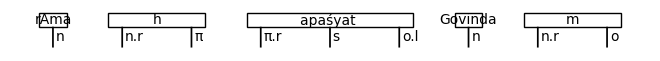

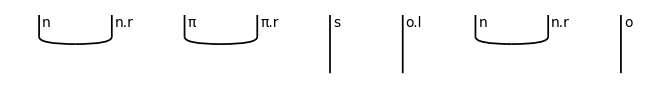

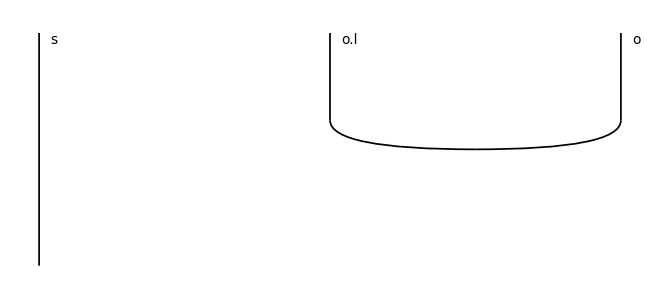

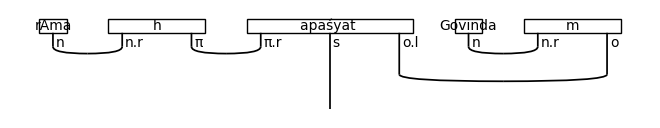

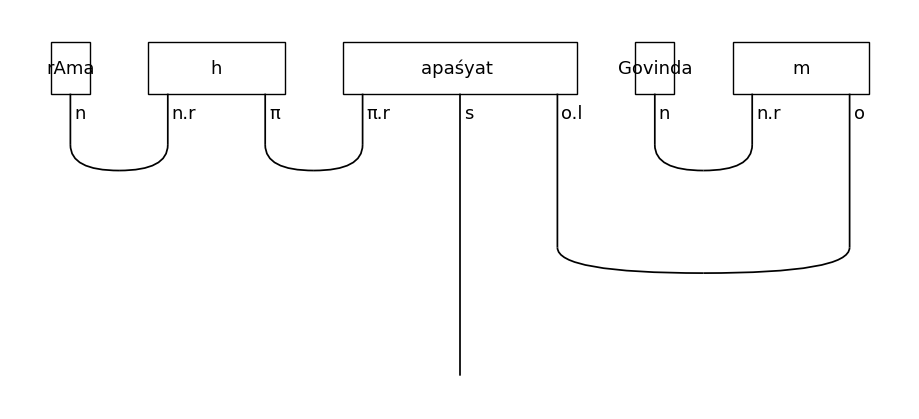

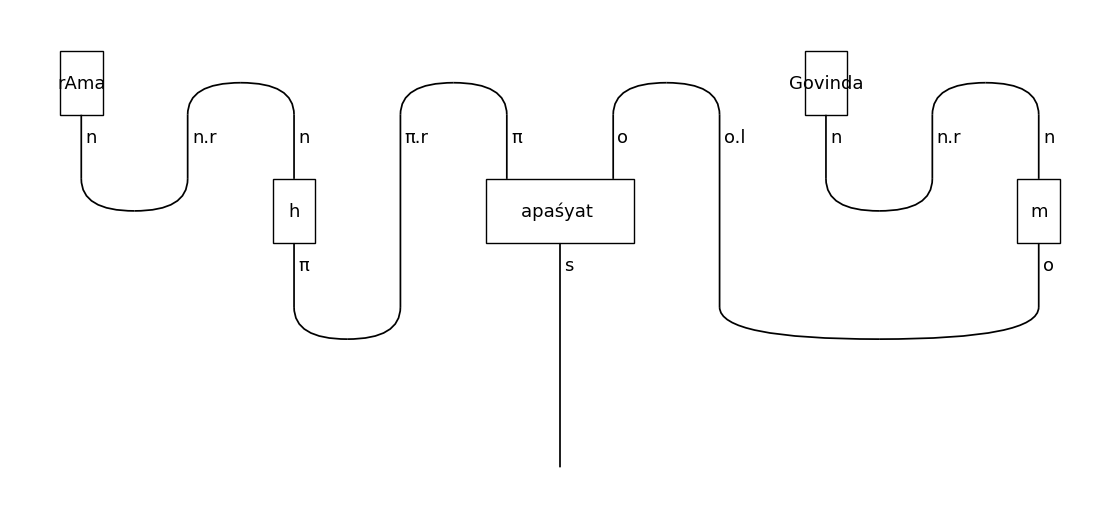

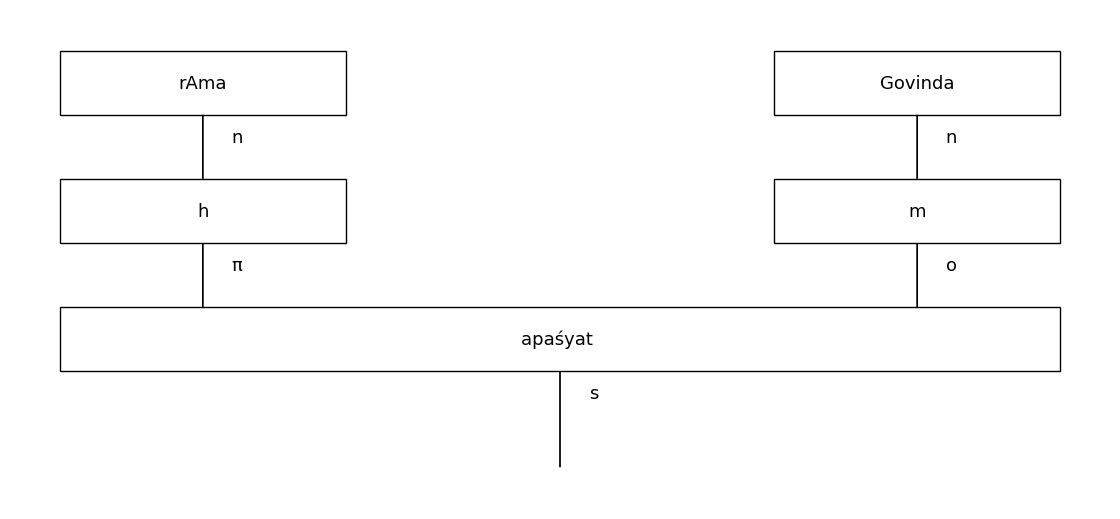

In [ ]:
from lambeq.backend.drawing import draw
from lambeq.backend.grammar import Cap, Cup, Id, Ty, Word
from lambeq import SpacyTokeniser
from lambeq import BobcatParser
from lambeq import Rewriter
# Basic types
dh = Ty('dh') # dhatu/root
n = Ty('n')  # noun phrase
s = Ty('s')  # sentence
p = Ty('p')  # predicate

pi = Ty('π') # nomative / prathamaa
o = Ty('o')  # accusative / dvitiiyaa
inst = Ty('inst') # instrumentive
dat = Ty('dat') # datative
abl = Ty('abl') # ablative
gen = Ty('gen') # genitive
loc = Ty('loc') # locative
voc = Ty('voc') # vocative

adj = Ty('adj') # adjective

rho = Ty('ρ') # subject of a predicative copular

cpd_adj = Ty('cpd_adj') # copular adjective

# Subject and object enlargements (modifiers)
subj_enl = pi.r @ pi
obj_enl = o.r @ o
pred_enl = p.r @ p

# Intransitive and transitive verbs
intrans_verb = pi.r @ s
trans_verb = pi.r @ s @ o.l

# Copular verbs
exist_copula = pi.r @ s
pred_copula = rho.r @ s @ p.l

# Adverb
adverb = s.r @ s

# Case morphemes
nom_morph = n.r @ pi
acc_morph = n.r @ o

# Example: "Rama saw Govinda"
words = [Word('rAma', n), Word('h', nom_morph), Word('apaśyat ', trans_verb), Word('Govinda', n), Word('m', acc_morph)]

sentence = words[0] @ words[1] @ words[2] @ words[3] @ words[4]

draw(sentence)

cups = Cup(n, n.r) @ Cup(pi, pi.r) @ Id(s) @ Id(o.l) @ Cup(n, n.r) @ Id(o)
cups1 = Id(s) @ Cup(o.l,o)
draw(cups)
draw(cups1)
# Apply the reductions to the sentence

diagram = Id().tensor(*words) >> cups >> cups1
# Draw the diagrams
draw(diagram)
# Apply rewrite rule for prepositional phrases
rewriter = Rewriter(['prepositional_phrase', 'determiner'])
rewritten_diagram = rewriter(diagram)
#normalize
normalised_diagram = rewritten_diagram.normal_form()
normalised_diagram.draw(figsize=(9,4), fontsize=13)

# Apply rewrite rule for conjunctions
rewriter = Rewriter(['curry'])
rewritten_diagram = rewriter(diagram)
rewritten_diagram.draw(figsize=(11,5), fontsize=13)
rewritten_diagram.normal_form().draw(figsize=(11,5), fontsize=13)

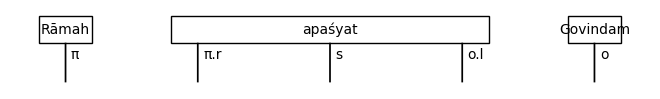

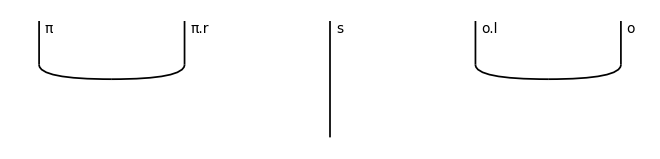

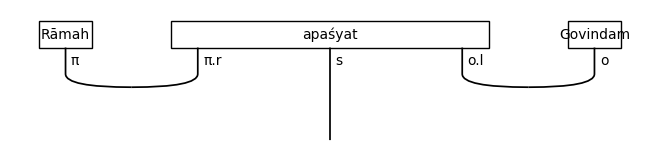

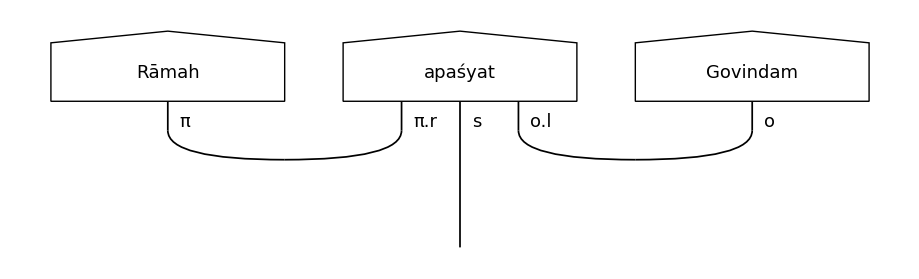

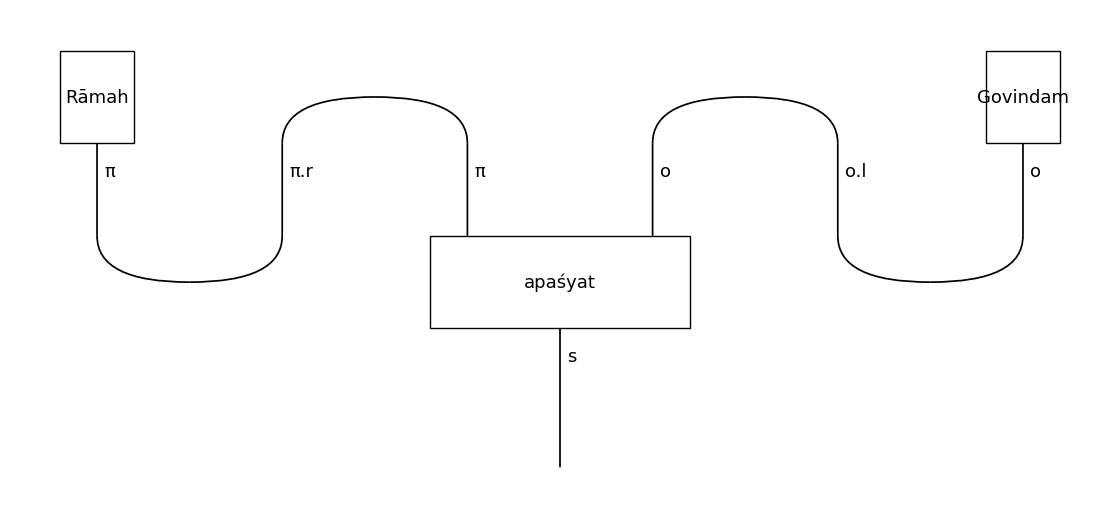

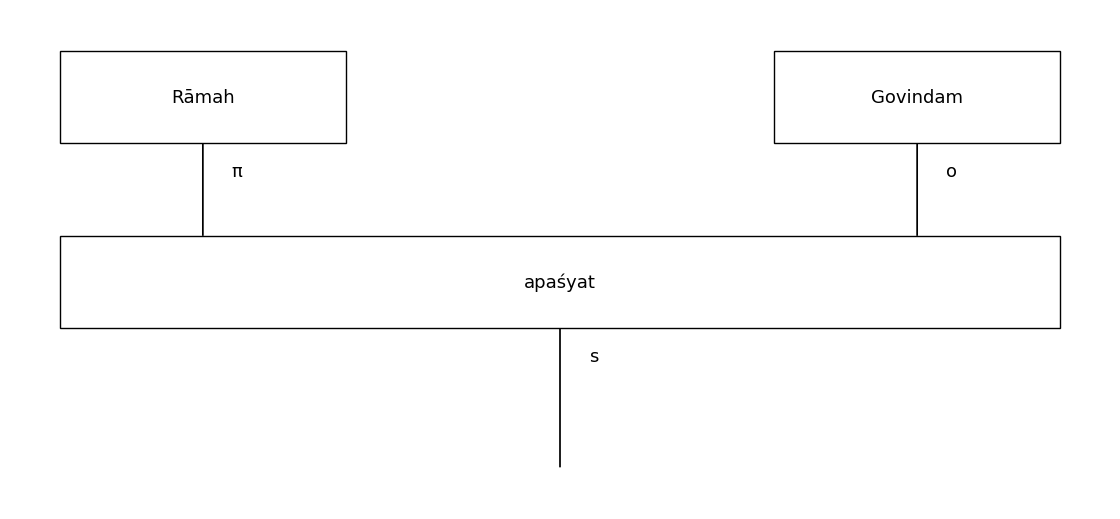

In [ ]:
words = [Word('Rāmah', pi), Word('apaśyat', trans_verb), Word('Govindam', o)]
sentence = words[0] @ words[1] @ words[2]
draw(sentence)
cups = Cup(pi, pi.r) @ Id(s) @ Cup(o.l, o)
draw(cups)
diagram = Id().tensor(*words) >> cups
draw(diagram)

rewriter = Rewriter(['prepositional_phrase', 'determiner'])
rewritten_diagram = rewriter(diagram)
rewritten_diagram.draw(figsize=(9,4), fontsize=13)

rewriter = Rewriter(['curry'])
rewritten_diagram = rewriter(diagram)
rewritten_diagram.draw(figsize=(11,5), fontsize=13)
rewritten_diagram.normal_form().draw(figsize=(11,5), fontsize=13)

Parameterize using https://cqcl.github.io/lambeq/tutorials/training-symbols.html

In [ ]:
import matplotlib.font_manager as fm
from lambeq import SpacyTokeniser, BobcatParser

# Path to the Devanagari font file
font_path = '/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf'

# Add the font to Matplotlib
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)

def sentence_to_diagram(sentence):
    tokeniser = SpacyTokeniser()
    tokens = tokeniser.tokenise_sentence(sentence)
    parser = BobcatParser(verbose='suppress')
    diagram = parser.sentence2diagram(tokens, tokenised=True)
    diagram.draw(figsize=(23, 4), fontproperties=prop, fontsize=12)

# Example usage
sentence_to_diagram('rAma')

In [ ]:
from lambeq import SpacyTokeniser
from lambeq import BobcatParser

tokeniser = SpacyTokeniser()
sentence = "Alice likes the flowers that Bob gives Claire"
tokens = tokeniser.tokenise_sentence(sentence)

parser = BobcatParser(verbose='suppress')
diagram = parser.sentence2diagram(tokens, tokenised=True)

diagram.draw(figsize=(23,4), fontsize=12)

In [ ]:
from lambeq import SpacyTokeniser
from lambeq import BobcatParser

tokeniser = SpacyTokeniser()
sentence = "Bob gives Claire the flowers that Alice likes"
tokens = tokeniser.tokenise_sentence(sentence)

parser = BobcatParser(verbose='suppress')
diagram = parser.sentence2diagram(tokens, tokenised=True)

diagram.draw(figsize=(23,4), fontsize=12)

In [ ]:
from lambeq import SpacyTokeniser
from lambeq import BobcatParser

tokeniser = SpacyTokeniser()
sentence = "John does not like Mary at all."
tokens = tokeniser.tokenise_sentence(sentence)

parser = BobcatParser(verbose='suppress')
diagram = parser.sentence2diagram(tokens, tokenised=True)

diagram.normal_form().draw(figsize=(23,4), fontsize=12)

In [ ]:
from lambeq import Rewriter
rewriter = Rewriter(['prepositional_phrase', 'determiner','curry'])
rewritten_diagram = rewriter(diagram)
rewritten_diagram.normal_form().draw(figsize=(9,4), fontsize=13)

In [ ]:
from lambeq import SpacyTokeniser
from lambeq import BobcatParser

sentence = "I am राम"
sentence_to_diagram(sentence)

In [ ]:
Words = [Word('kaḥ', s @ (s.l @ n)), Word('[asti]', pred_copula), Word('ayam', p)]
sentence = Words[0] @ Words[1] @ Words[2]
draw(sentence)
cups = Cup(rho, rho.r) @ Id(s) @ Cup(p.l, p)
draw(cups)
diagram = Id().tensor(*Words) >> cups
draw(diagram)